In [2]:
import seaborn as sns
tips = sns.load_dataset("tips")     # 시바로 제공되는 예제 데이터
print(tips.head())                  # 상위 5개
print(tips.describe())              # 개수·평균·표준편차·최소·최대

# 그룹별 통계: 요일별 팁 평균
print(tips.groupby("day")["tip"].mean())
print(tips.groupby("day")["tip"].agg(["mean", "std", "min", "max"]))

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000
day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64
          mean       std   min    max
day                                  
Thur  2.771452  1.240223  1.25   6.70
Fri   2.734737  1.019577  1.00   4.73
Sat   2.993103  1.631014  1.00  10.00
Sun   3.25

C:\Users\it\AppData\Local\Temp\ipykernel_23632\3837260470.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupby("day")["tip"].mean())
C:\Users\it\AppData\Local\Temp\ipykernel_23632\3837260470.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupby("day")["tip"].agg(["mean", "std", "min", "max"]))


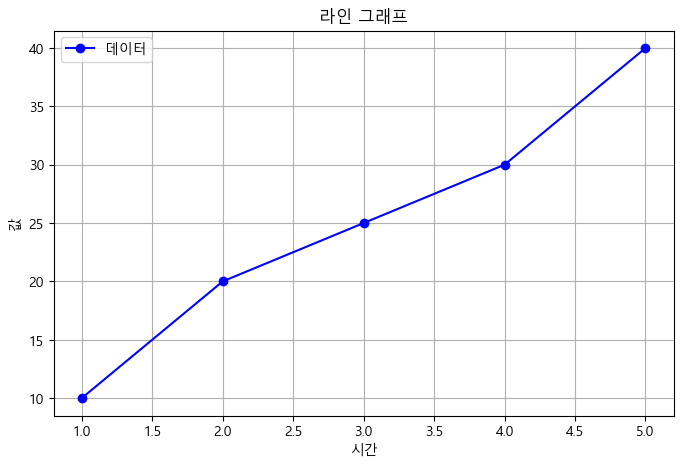

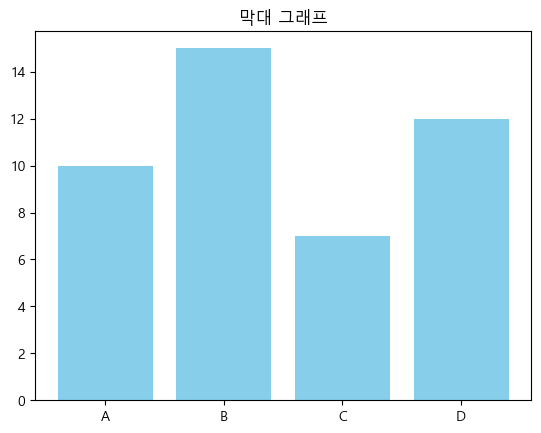

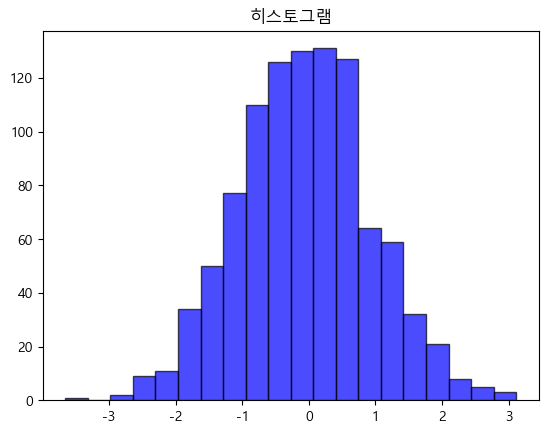

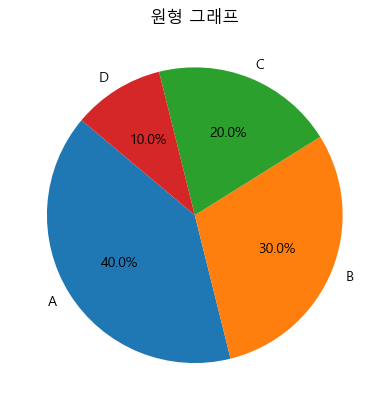

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False   # 음수 기호 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# (위 0번의 한글 폰트 설정을 먼저 실행)

# 1) 라인 그래프 — 추세
x = [1, 2, 3, 4, 5]
y = [10, 20, 25, 30, 40]
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linestyle='-', color='b', label='데이터')
plt.title('라인 그래프'); plt.xlabel('시간'); plt.ylabel('값')
plt.legend(); plt.grid(True)
plt.show()

# 2) 막대 그래프 — 카테고리 비교
plt.bar(['A', 'B', 'C', 'D'], [10, 15, 7, 12], color='skyblue')
plt.title('막대 그래프'); plt.show()

# 3) 히스토그램 — 분포
data = np.random.randn(1000)
plt.hist(data, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.title('히스토그램'); plt.show()

# 4) 원형 그래프 — 비율
plt.pie([40, 30, 20, 10], labels=['A','B','C','D'], autopct='%1.1f%%', startangle=140)
plt.title('원형 그래프'); plt.show()

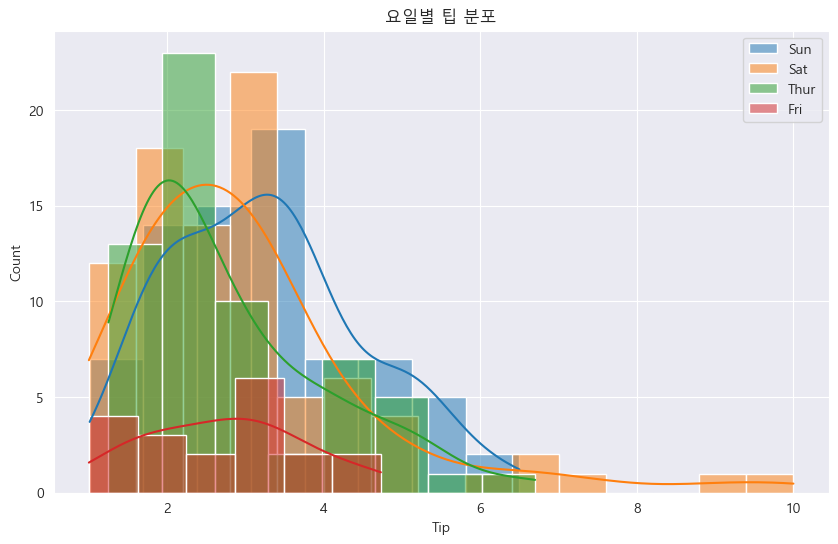

In [4]:
import platform
import seaborn as sns  # seaborn 임포트 추가

import matplotlib.pyplot as plt

# Seaborn 스타일을 먼저 설정합니다. (이때 기본 폰트로 리셋됨)
sns.set_style("darkgrid")

plt.rcParams['axes.unicode_minus'] = False   # 음수 기호 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# (위 0번의 한글 폰트 설정을 먼저 실행)

# 2. 그래프 그리기
# (예시용 데이터 로드: seaborn 내장 데이터)
tips = sns.load_dataset("tips")


plt.figure(figsize=(10, 6)) # 그래프 크기 설정 추가

for day in tips["day"].unique():
    subset = tips[tips["day"] == day]
    sns.histplot(subset["tip"], kde=True, label=day)

plt.title("요일별 팁 분포")
plt.xlabel("Tip")
plt.legend()
plt.show()

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


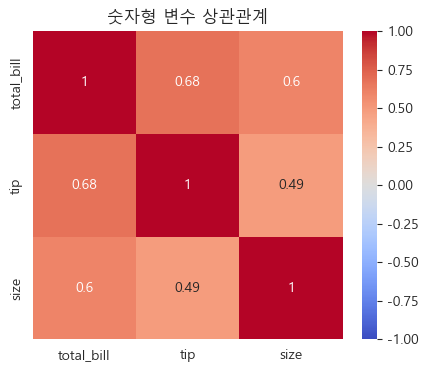

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False   # 음수 기호 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'

num_cols = ["total_bill", "tip", "size"]   # 숫자형 열만
corr_matrix = tips[num_cols].corr()         # 상관계수 행렬
print(corr_matrix)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
# annot=True: 칸안에 숫자 표시 / coolwarm: 음=파랑, 양=빨강
plt.title("숫자형 변수 상관관계"); plt.show()

In [6]:
import statsmodels.api as sm
X = tips[["total_bill", "size"]]   # 독립변수
y = tips["tip"]                     # 종속변수
X = sm.add_constant(X)             # 절편(상수항) 추가
model = sm.OLS(y, X).fit()         # 모델 적합
print(model.summary())             # R-squared, coef, p-값 등 전체 요약

# 해석 포인트: P>|t| 값이 0.05 미만인 변수가 tip에 유의미한 영향

ModuleNotFoundError: No module named 'statsmodels'